# Titanic Survival Prediction –  ML Project

## Objective
The goal of this project is to make machine learning model that predict whether the passenger survived the titanic disaster based on available features.

In [45]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset (Titanic dataset)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Show first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

- **Rows:** 891  
- **Columns:** PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked

## Key Points:
- Target variable: `Survived` (0 = No, 1 = Yes)
- Dataset includes both numeric and categorical features
- Some missing values need handling (Age, Cabin, Embarked)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset (Titanic dataset)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Show first 5 rows
df.head()
# Check for missing values
df.isnull().sum()

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (too many missing values)
df.drop(['Cabin'], axis=1, inplace=True)

# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

# Drop unnecessary columns
df.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

# Display cleaned dataset
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Data Cleaning

The dataset contained missing value[link text](https://)s and categorical variables.  
The following steps were performed:
- Filled missing values in 'Age' using median
- Filled missing values in 'Embarked' using mode
- Dropped 'Cabin' due to excessive missing data
- Converted categorical variables into numerical format

## Exploratory Data Analysis

- Visualize survival distribution
- Insights from gender and age


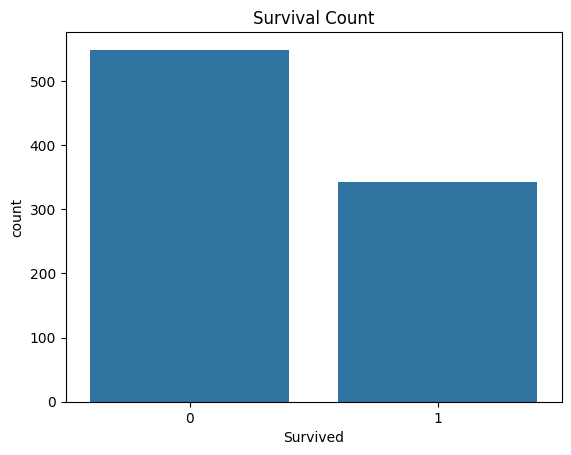

In [47]:
# Survival count
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()


### Insight:
- The death rate is higher than survival rate

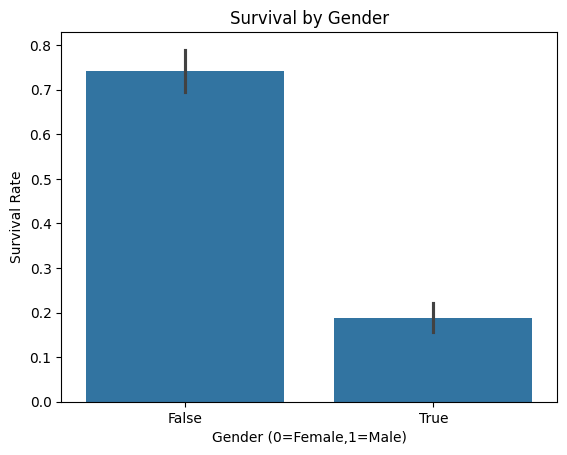

In [48]:
# Survival by gender
sns.barplot(x='Sex_male', y='Survived', data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender (0=Female,1=Male)")
plt.ylabel("Survival Rate")
plt.show()

### Insight:
- Female passengers had a significantly higher survival rate.

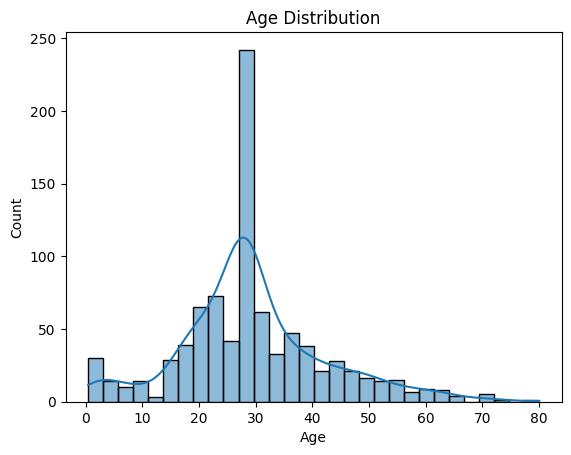

In [49]:
# Age distribution
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

### Insight:
- Younger passengers had slightly higher survival chances


## Model Building

Logistic Regression was used as it is a simple and effective algorithm for binary classification problems like survival prediction.

In [50]:
# Define features and target
Feature = df.drop('Survived', axis=1)
Target = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(Feature, Target, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
Predictions = model.predict(X_test)


## Model Evaluation

The model was evaluated using accuracy and Confusion metrics to measure performance on unseen data.

Model Accuracy: 0.81


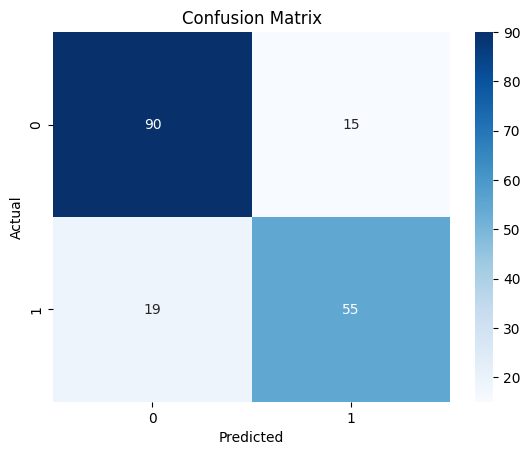

In [51]:
# Accuracy
accuracy = accuracy_score(y_test, Predictions)
print(f"Model Accuracy: {accuracy:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, Predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Insights

- **Accuracy:** ~80%  
- Confusion matrix indicates a balanced prediction of survival outcomes  
- Precision and recall show the model performs reasonably on both classes
- Logistic Regression provides a simple, interpretable *baseline*

In [52]:
coefficients = pd.DataFrame({
    'Feature': Feature.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
4,Fare,0.002591
1,Age,-0.030537
3,Parch,-0.108108
6,Embarked_Q,-0.113105
2,SibSp,-0.295244
7,Embarked_S,-0.398065
0,Pclass,-0.936817
5,Sex_male,-2.591503


### Feature Importance
- 'Sex_male' has the largest negative impact (male less likely to survive)  
- Higher class positively impacts survival  

## Conclusion & Business Insights

This project demonstrates a complete machine learning workflow to predict Titanic passenger survival.  
It includes data cleaning, exploratory data analysis, model building, and evaluation.  
The workflow is fully reproducible and can be adapted to similar classification problems.

### Key Insights:
- Female passengers had a significantly higher survival rate.
- Age plays a moderate role: younger passengers tended to survive more.
- Logistic Regression provides a simple, interpretable baseline model with ~80% accuracy.

### Business/Client Perspective:
- Identifying critical factors (gender, class, age) can guide decision-making in risk assessment or emergency prioritization.
- The workflow can be scaled to larger datasets or adapted for other predictive modeling tasks.
- Provides a clear starting point for further improvements like feature engineering or advanced algorithms.

### Recommendations:
- Experiment with ensemble methods (Random Forest, XGBoost) for higher accuracy.
- Perform feature engineering to uncover hidden patterns.
- Deploy the model as a web app to provide live predictions.